# Title: Supplementary Graphs for the DACCS Meta-Analysis
## Description: This code was developed to plot graphs for the meta-analysis on DACCS
**Authors:**  Yash Dubey, Katrin Sievert 

In [67]:
# Libraries 
import pandas as pd
import numpy as np
import xlsxwriter
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

In [68]:
df = pd.read_excel("../data/Master Standardisation DACCS.xlsx", sheet_name="Standardization Results", skiprows=1)

In [69]:
# Drop rows where technology is 0
df = df[df['DAC Technology'] != 0]
df = df.dropna(subset = "Baseline $2023 Any Cost Type")

In [70]:
df.replace("Ambient Weathering", "Ambient weathering", inplace=True)
df.loc[:,"DAC Technology"] = df.loc[:,"DAC Technology"].str.strip()

In [71]:
# Drop membrane based
df = df[df['DAC Technology'] != "Membrane-based m-DAC"]

In [72]:
# Year of assumption before 2024
df.loc[:,"Year of Assumptions in Study"] = df["Year of Assumptions in Study"].astype(int)
df_short = df[df['Year of Assumptions in Study'] < 2025]

In [73]:
# Export descriptive statistics for short term
df_short.loc[:,["Baseline $2023 Any Cost Type", "Year of Cost", "DAC Technology"]].groupby("DAC Technology").describe().to_excel("/Users/yash/Desktop/DACCS/Short_Term_Descriptive_Statistics.xlsx")

In [74]:
df['Cost type'].unique()

array(['Net removed cost', 'Levelised Cost of Removal', nan,
       'Levelized cost of capture',
       'Levelized cost of CO2 avoided (without transport and storage)',
       'Cost of capture, transport, storage',
       'Cost of CO2 avoided (without transport and storage)'],
      dtype=object)

In [75]:
data = []
for tech in df['DAC Technology'].unique():
    data.append(tech)
data

['Liquid solvent',
 'Solid sorbent',
 'Liquid solvent with electrochemical regeneration',
 'Ambient weathering']

<>:55: SyntaxWarning: invalid escape sequence '\$'
<>:55: SyntaxWarning: invalid escape sequence '\$'
/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_55573/1053095175.py:55: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel('LCOR (\$$_{2023}$/tCO2)')
/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_55573/1053095175.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks, rotation=0)


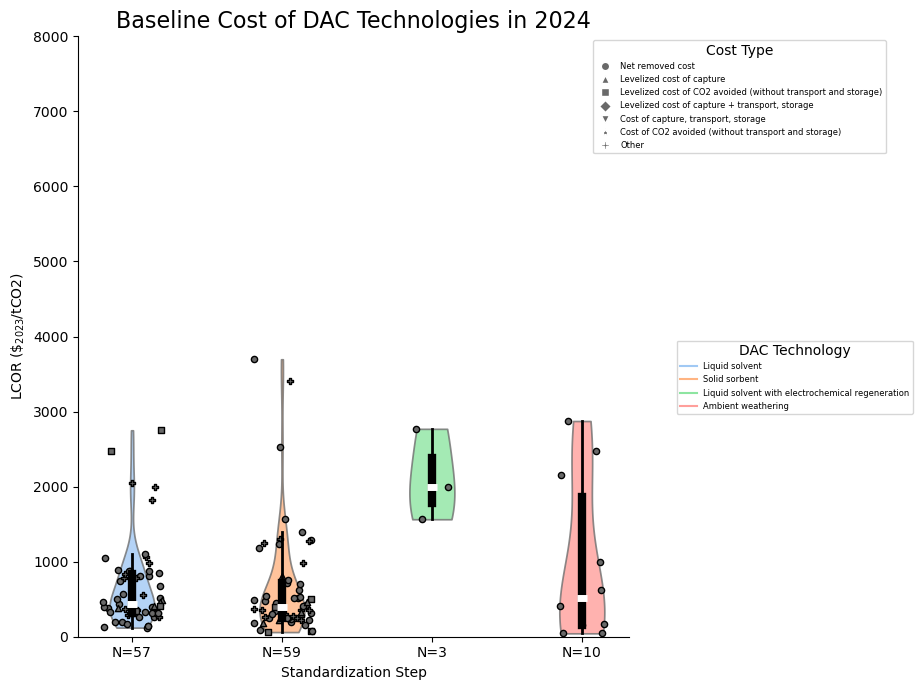

In [76]:
# Calculate the number of observations for each DAC Technology
obs_counts = df_short.groupby('DAC Technology')['Baseline $2023 Any Cost Type'].count()

# Violin plot of data
boxplot_data = [df_short[df_short['DAC Technology'] == tech]['Baseline $2023 Any Cost Type'] for tech in data]

fig, ax = plt.subplots(figsize=(10, 7))
sns.violinplot(data=df_short, x="DAC Technology", y="Baseline $2023 Any Cost Type", hue="DAC Technology", legend=False, inner="box", 
               inner_kws=dict(color="black", box_width=6, whis_width=2, markersize=7, markeredgewidth=5), 
               palette="pastel", saturation=1, cut=0, width=0.3, orient='v', alpha=0.8)
plt.ylim(0, 8000)

# Scatter plot of 2024 cost data overlaid on the violin plot
cost_type_markers = {
    'Net removed cost': 'o',  # Circle
    'Levelized cost of capture': '^',  # Triangle
    'Levelized cost of CO2 avoided (without transport and storage)': 's',  # Square
    'Levelized cost of capture + transport, storage': 'D',  # Diamond
    'Cost of capture, transport, storage': 'v',  # Downward triangle
    'Cost of CO2 avoided (without transport and storage)': '*',  # Star
}

pastel_colors = sns.color_palette("pastel", 4)

# Assign the pastel colors to your labels
label_colors = {
    'Liquid solvent': pastel_colors[0],  # blue-like color
    'Solid sorbent': pastel_colors[1],   # green-like color
    'Liquid solvent with electrochemical regeneration': pastel_colors[2],  # red-like color
    'Ambient weathering': pastel_colors[3],  # purple-like color
}

jitter_strength = 0.2  # Adjust the jitter as needed

# Loop through the data and plot scatter points for each row
positions = range(len(boxplot_data))  # x-axis position for the baseline
for pos in positions:
    baseline_values = df_short[df_short['DAC Technology'] == data[pos]]['Baseline $2023 Any Cost Type']
    tech_column = df_short['Cost type']

    for value, tech in zip(baseline_values, tech_column):
        marker = cost_type_markers.get(tech, 'P')  # Default to 'P' if technology not found
        jittered_pos = pos + np.random.uniform(-jitter_strength, jitter_strength)
        ax.scatter(jittered_pos, value, alpha=1, marker=marker, edgecolor='black', facecolor='dimgrey', s=20)

# Update x-ticks with number of observations
x_ticks = [f"N={obs_counts[tech]}" for tech in label_colors.keys()]
ax.set_xticklabels(x_ticks, rotation=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the title and labels
ax.set_title('Baseline Cost of DAC Technologies in 2024', fontsize=16)
ax.set_ylabel('LCOR (\$$_{2023}$/tCO2)')
ax.set_xlabel('Standardization Step')

# Add the first legend for the scatter plot markers (Cost Type)
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=tech, markerfacecolor='dimgrey', markersize=6) 
                   for tech, marker in cost_type_markers.items()]
legend_elements.append(plt.Line2D([0], [0], marker='P', color='w', label='Other', markerfacecolor='dimgrey', markersize=6))
first_legend = ax.legend(handles=legend_elements, title='Cost Type', loc='upper center', bbox_to_anchor=(1.2, 1), prop={'size': 6})

# Add the second legend for the x-axis labels (DAC Technology)
label_handles = [plt.Line2D([0], [0], color=color, label=label, markerfacecolor='w', markersize=6) 
                 for label, color in label_colors.items()]
second_legend = ax.legend(handles=label_handles, title='DAC Technology', loc='upper center', bbox_to_anchor=(1.3, 0.5), prop={'size': 6})

# Add the first legend back to the plot
ax.add_artist(first_legend)

plt.tight_layout()
plt.show()

In [77]:
df_2030 = df[df['Year of Assumptions in Study'] == 2030]
df_2050 = df[df['Year of Assumptions in Study'] == 2050]

In [78]:
# Export descriptive statistics for short term
df_2050.loc[:,["Baseline $2023 Any Cost Type", "Year of Cost", "DAC Technology"]].groupby("DAC Technology").describe().to_excel("/Users/yash/Desktop/DACCS/Long_Term_Descriptive_Statistics.xlsx")


/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_55573/1070100650.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks, rotation=0)


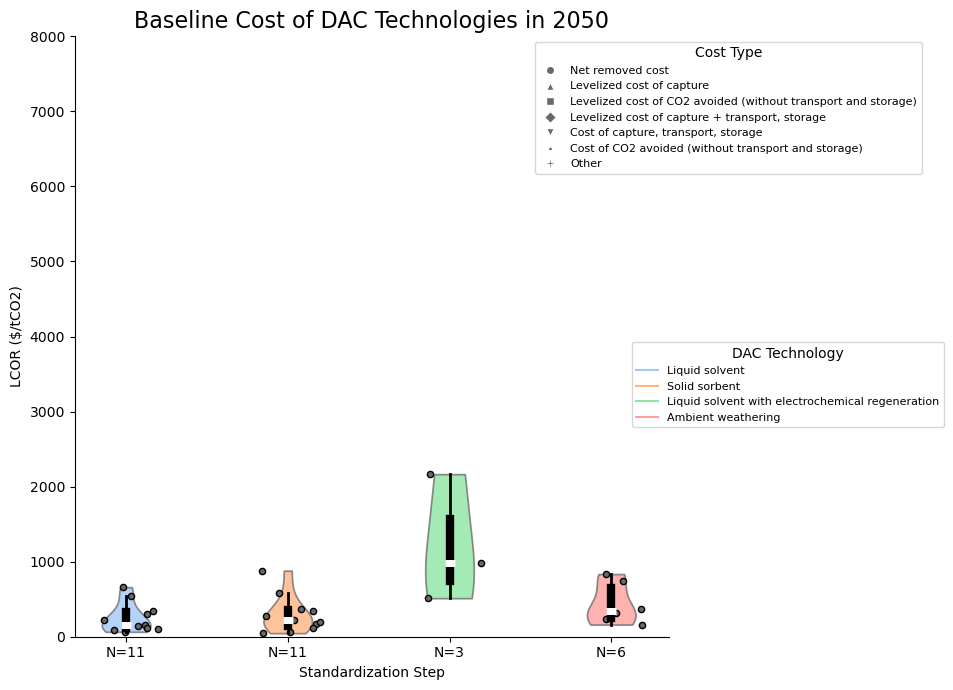

In [79]:
# Same plot for 2050

# Calculate the number of observations for each DAC Technology
obs_counts = df_2050.groupby('DAC Technology')['Baseline $2023 Any Cost Type'].count()

# Violin plot of data
boxplot_data = [df_2050[df_2050['DAC Technology'] == tech]['Baseline $2023 Any Cost Type'] for tech in data]

fig, ax = plt.subplots(figsize=(10, 7))

sns.violinplot(data=df_2050, x="DAC Technology", y="Baseline $2023 Any Cost Type", hue="DAC Technology", legend=False, inner="box",
                inner_kws=dict(color="black", box_width=6, whis_width=2, markersize=7, markeredgewidth=5),
                palette="pastel", saturation=1, cut=0, width=0.3, orient='v', alpha=0.8)

plt.ylim(0, 8000)

# Scatter plot of 2050 cost data overlaid on the violin plot
cost_type_markers = {
    'Net removed cost': 'o',  # Circle
    'Levelized cost of capture': '^',  # Triangle
    'Levelized cost of CO2 avoided (without transport and storage)': 's',  # Square
    'Levelized cost of capture + transport, storage': 'D',  # Diamond
    'Cost of capture, transport, storage': 'v',  # Downward triangle
    'Cost of CO2 avoided (without transport and storage)': '*',  # Star
}

pastel_colors = sns.color_palette("pastel", 5)

# Assign the pastel colors to your labels
label_colors = {
    'Liquid solvent': pastel_colors[0],  # blue-like color
    'Solid sorbent': pastel_colors[1],  # green-like color
    'Liquid solvent with electrochemical regeneration': pastel_colors[2],  # red-like color
    'Ambient weathering': pastel_colors[3],  # purple-like color
}

jitter_strength = 0.2  # Adjust the jitter as needed

# Loop through the data and plot scatter points for each row
positions = range(len(boxplot_data))  # x-axis position for the baseline
for pos in positions:
    baseline_values = df_2050[df_2050['DAC Technology'] == data[pos]]['Baseline $2023 Any Cost Type']
    tech_column = df_2050['Cost type']

    for value, tech in zip(baseline_values, tech_column):
        marker = cost_type_markers.get(tech, 'P')  # Default to 'P' if technology not found
        jittered_pos = pos + np.random.uniform(-jitter_strength, jitter_strength)
        ax.scatter(jittered_pos, value, alpha=1, marker=marker, edgecolor='black', facecolor='dimgrey', s=20)

# Update x-ticks with number of observations
x_ticks = [f"N={obs_counts[tech]}" for tech in label_colors.keys() if tech in obs_counts]
ax.set_xticklabels(x_ticks, rotation=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the title and labels
ax.set_title('Baseline Cost of DAC Technologies in 2050', fontsize=16)
ax.set_ylabel('LCOR ($/tCO2)')
ax.set_xlabel('Standardization Step')

# Add the first legend for the scatter plot markers (Cost Type)
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=tech, markerfacecolor='dimgrey', markersize=6)
                   for tech, marker in cost_type_markers.items()]
legend_elements.append(plt.Line2D([0], [0], marker='P', color='w', label='Other', markerfacecolor='dimgrey', markersize=6))
first_legend = ax.legend(handles=legend_elements, title='Cost Type', loc='upper center', bbox_to_anchor=(1.1, 1), prop={'size': 8})

# Add the second legend for the x-axis labels (DAC Technology)
label_handles = [plt.Line2D([0], [0], color=color, label=label, markerfacecolor='w', markersize=6)
                 for label, color in label_colors.items()]

second_legend = ax.legend(handles=label_handles, title='DAC Technology', loc='upper center', bbox_to_anchor=(1.2, 0.5), prop={'size': 8})

# Add the first legend back to the plot
ax.add_artist(first_legend)

plt.tight_layout()
plt.show()




In [80]:
import re
def extract_year(text):
    match = re.search(r'\d{4}', text)
    return match.group(0) if match else None

In [81]:
df['pub_year'] = df['Reference'].apply(extract_year)

In [82]:
df['pub_year'] = df['pub_year'].astype(int)

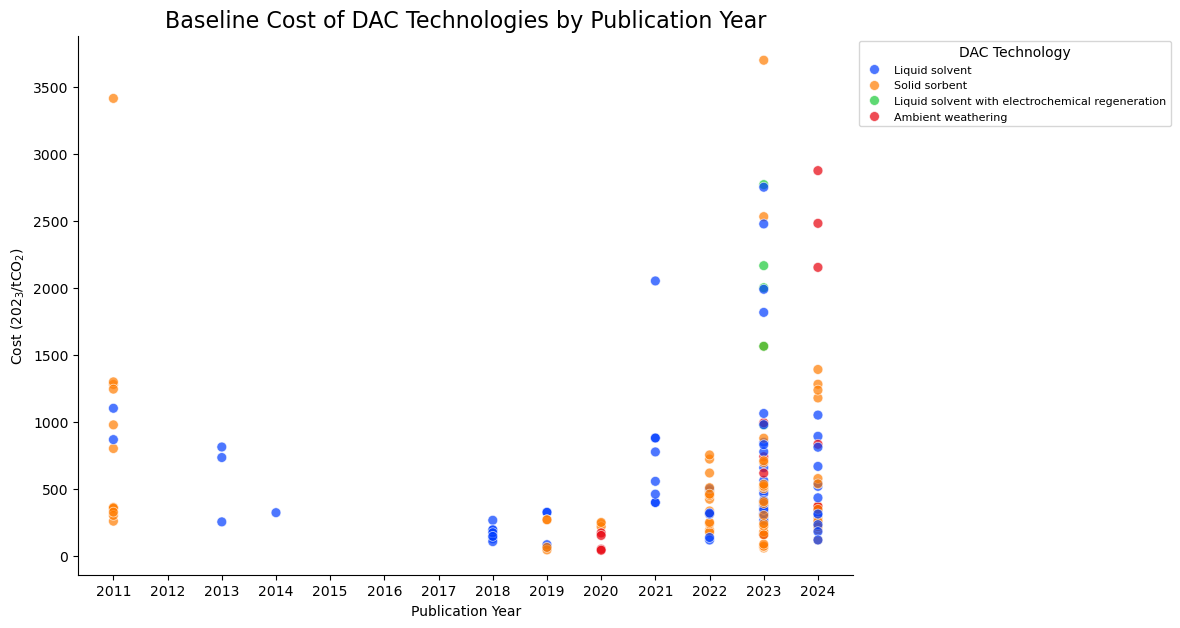

In [83]:
# Plot with a continuous x-axis for publication year
fig, ax = plt.subplots(figsize=(10, 7))

# Use scatter plot with continuous x-axis for pub_year
sns.scatterplot(data=df, x="pub_year", y="Baseline $2023 Any Cost Type", 
                hue="DAC Technology", palette="bright", s=50, alpha=0.7)

# Adjust x-axis to show 5-year intervals
ax.set_xticks(range(df['pub_year'].min(), df['pub_year'].max() + 1, 1))

# Set the title and labels
ax.set_title('Baseline Cost of DAC Technologies by Publication Year', fontsize=16)
ax.set_ylabel(r'Cost ($202_{3}$/tCO$_2$)')
ax.set_xlabel('Publication Year')

# Hide top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(title='DAC Technology', loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 8})

plt.show()

In [84]:
sensitivity_df = pd.read_excel("../data/Master Standardisation DACCS.xlsx", sheet_name="Study Selection Step 1")

In [85]:
sensitivities = sensitivity_df['Sensitive Parameters'].str.split(',').explode().str.strip().value_counts().reset_index()
sensitivities.columns = ['Sensitive Parameters', 'Count']
sensitivities = sensitivities[sensitivities['Sensitive Parameters'] != '/']

In [86]:
sensitivity_df['DAC Technology'].unique()

array(['Liquid solvent', 'Solid sorbent',
       'Liquid solvent with electrochemical regeneration',
       'Ambient weathering', 'Liquid solvent ', 'Membrane-based m-DAC',
       'Generic (Solid sorbent referenced)', nan,
       'Electro-swing adsorption (ESA)', 'Ambient Weathering'],
      dtype=object)

In [87]:
sensitivity_df = sensitivity_df[sensitivity_df['Sensitive Parameters'] != '/']
sensitivity_df['Sensitive Parameters'] = sensitivity_df['Sensitive Parameters'].str.replace(
    "Carbon mineralization efficiency \(mass fraction of caustic MgO converted to MgCO3\)", 
    "Carbon Mineralization Efficiency", 
    regex=True
)

<>:3: SyntaxWarning: invalid escape sequence '\('
<>:3: SyntaxWarning: invalid escape sequence '\('
/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_55573/3459154052.py:3: SyntaxWarning: invalid escape sequence '\('
  "Carbon mineralization efficiency \(mass fraction of caustic MgO converted to MgCO3\)",


/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_55573/1707630587.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Parameter', data=sensitivity_counts, ax=ax, palette="viridis")
/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_55573/1707630587.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Parameter', data=sensitivity_counts, ax=ax, palette="viridis")
/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_55573/1707630587.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cou

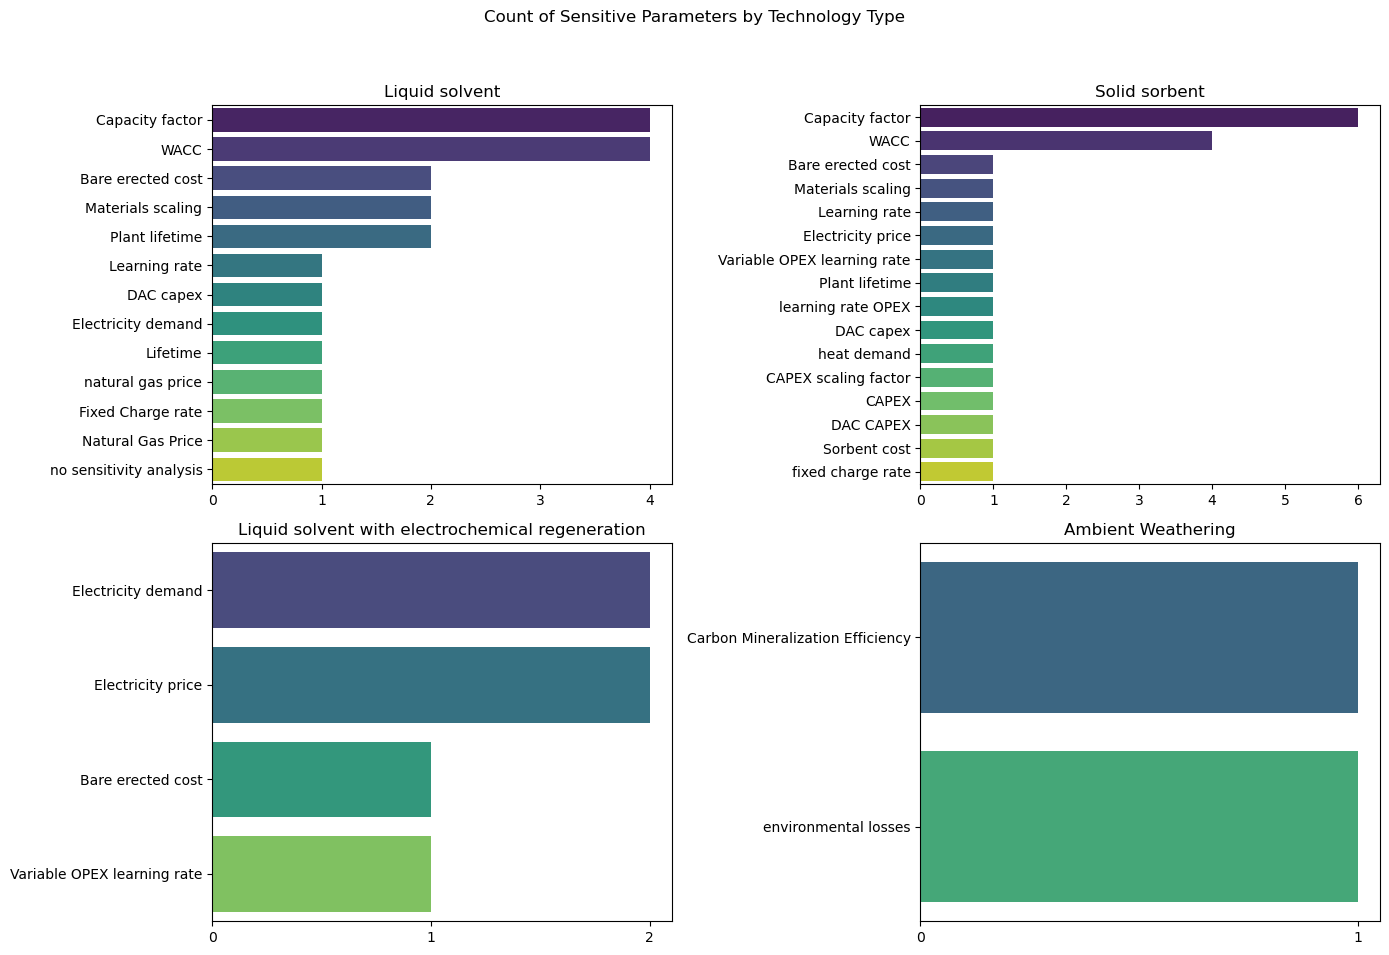

In [88]:
tech_types_to_keep = [
    'Liquid solvent', 
    'Solid sorbent', 
    'Liquid solvent with electrochemical regeneration', 
    'Ambient Weathering'
]

sensitivity_df = sensitivity_df[sensitivity_df['DAC Technology'].isin(tech_types_to_keep)]

# Create a 2x2 grid plot
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Count of Sensitive Parameters by Technology Type')

# Loop through each technology type
for i, (tech_type, ax) in enumerate(zip(tech_types_to_keep, axs.flat)):
    # Filter data for each technology type
    tech_df = sensitivity_df[sensitivity_df['DAC Technology'] == tech_type]
    
    # Split parameters, explode, and count occurrences
    sensitivity_counts = tech_df['Sensitive Parameters'].str.split(',').explode().str.strip().value_counts().reset_index()
    sensitivity_counts.columns = ['Parameter', 'Count']
    
    # Plot the bar chart for each technology type
    sns.barplot(x='Count', y='Parameter', data=sensitivity_counts, ax=ax, palette="viridis")
    ax.set_title(tech_type)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Ensure x-ticks are integers only
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
plt.show()

In [89]:
# Load synfuels data
synfuels_df_med = pd.read_excel("../data/Master Standardisation_SAF.xlsx", sheet_name="Standardization Results", skiprows=0)
synfuels_df_high = pd.read_excel("../data/Master Standardisation_SAF.xlsx", sheet_name="High CO2", skiprows=0)
synfuels_df_low = pd.read_excel("../data/Master Standardisation_SAF.xlsx", sheet_name="Low CO2", skiprows=0)



In [90]:
# Select specific synfuels studies

studies_to_keep_synfuels = ["Brazzola et al. ", "Gray et al.", "Marchese et.al. ", "Martin et. al.", "Moretti et al.",
                     "Peacock et. al.", "Schmidt et. al.", "Seymour et al.", "Sherwin"]

synfuels_df_med = synfuels_df_med[synfuels_df_med['Reference'].isin(studies_to_keep_synfuels)]
synfuels_df_high = synfuels_df_high[synfuels_df_high['Reference'].isin(studies_to_keep_synfuels)]
synfuels_df_low = synfuels_df_low[synfuels_df_low['Reference'].isin(studies_to_keep_synfuels)]

synfuels_df_med["Year of Cost"] = synfuels_df_med["Year of Cost"].astype(int)
synfuels_df_high["Year of Cost"] = synfuels_df_high["Year of Cost"].astype(int)
synfuels_df_low["Year of Cost"] = synfuels_df_low["Year of Cost"].astype(int)

# Define a term column which is Short Term if Year of Cost is before 2030 and Long Term if after 2030
synfuels_df_med["Term"] = np.where(synfuels_df_med["Year of Cost"] < 2030, "Short Term", "Long Term")
synfuels_df_high["Term"] = np.where(synfuels_df_high["Year of Cost"] < 2030, "Short Term", "Long Term")
synfuels_df_low["Term"] = np.where(synfuels_df_low["Year of Cost"] < 2030, "Short Term", "Long Term")

synfuel_dfs = [synfuels_df_med, synfuels_df_high, synfuels_df_low]

In [91]:
# Select spcific DACCS studies from df 
#Young et al. 2023
#Sievert et al. 2024
#Fasihi et al. 2019
#Keith et al. 2018

studies_to_keep_daccs = ["Young et al. 2023", "Sievert et al. 2024", "Fasihi et al. 2019", "Keith et al. 2018", "Pett-Ridge et al. 2024"]
daccs_df = df[df['Reference'].isin(studies_to_keep_daccs)]
# Add the term column which is short term if year of assumption is less than 2030
daccs_df.loc[daccs_df['Year of Assumptions in Study'] < 2025, "Term"] = "Short Term"
daccs_df.loc[daccs_df['Year of Assumptions in Study'] >= 2025, "Term"] = "Long Term"

/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_55573/2517658174.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daccs_df.loc[daccs_df['Year of Assumptions in Study'] < 2025, "Term"] = "Short Term"


In [92]:
synfuels_df = pd.concat(synfuel_dfs)
synfuels_df

,Reference,Year of Assumptions in Study,DOI,Pathway,Pathway Detail,Year of Cost,Study Scenario,Baseline,LCOE Harmonized,CO2 Cost Harmonized,...,Residual Emissions (gCO2eq/L fuel),Electricity,CO2,CAPEX,Other OPEX,Study Type,Plant Location,Production,Unnamed: 19,Term
2,Brazzola et al.,2024,NaN,e-Fuels,Fischer Tropsch,2024,Reference,432.436036,859.504233,515.010985,...,0.000000,NaN,NaN,NaN,NaN,Academic,Worldwide,-,NaN,Short Term
3,Brazzola et al.,2024,NaN,e-Fuels,Fischer Tropsch,2050,Reference,226.434837,507.549635,304.121407,...,0.000000,NaN,NaN,NaN,NaN,Academic,Worldwide,-,NaN,Long Term
8,Gray et al.,2024,https://doi.org/10.1016/j.rser.2024.114552,e-Fuels,Fischer Tropsch,2024,Reference DAC Deployment,2727.577326,2805.955159,1585.537576,...,276.927077,0.340272,0.399784,0.177298,0.082646,Academic,Europe,39140033.75,NaN,Short Term
9,Gray et al.,2024,https://doi.org/10.1016/j.rser.2024.114552,e-Fuels,Fischer Tropsch,2050,High DAC Deployment,1053.015690,1131.393522,1286.760526,...,276.927077,0.411612,0.273944,0.214470,0.099974,Academic,Europe,39140033.75,This scenario assumes a decline in CO2 cost bu...,Long Term
10,Marchese et.al.,2021,https://doi.org/10.1016/j.jcou.2021.101487,e-Fuels,Fischer Tropsch,2024,C.4,1458.348939,751.427188,977.301001,...,0.000000,NaN,NaN,NaN,NaN,Academic,Europe,69000000,NaN,Short Term
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,Schmidt et. al.,2024,https://onlinelibrary.wiley.com/doi/full/10.10...,e-Fuels,Fischer Tropsch,2024,EU-South,1286.159301,1276.902166,1398.911869,...,204.668640,NaN,NaN,NaN,NaN,Industrial,Europe,1000000,NaN,Short Term
42,Seymour et al.,2024,https://doi.org/10.1039/D3SE00978E,e-Fuels,Fischer Tropsch,2050,Reference,722.872772,698.768145,632.728842,...,305.140000,0.476140,0.246474,0.181607,0.095779,Academic,United States of America,2110761,NaN,Long Term
43,Seymour et al.,2024,https://doi.org/10.1039/D3SE00978E,e-Fuels,Fischer Tropsch,2024,Reference,1703.294188,1744.099290,1199.238291,...,305.140000,0.467868,0.195624,0.220833,0.115675,Academic,United States of America,2110761,"High CO2 cost assumed, hence there is less effect",Short Term
44,Sherwin,2021,https://doi.org/10.1021/acs.est.0c07955,e-Fuels,Fischer Tropsch,2024,Reference,1330.231544,1583.370213,1312.728828,...,0.000000,NaN,NaN,NaN,NaN,Academic,United States of America,-,NaN,Short Term


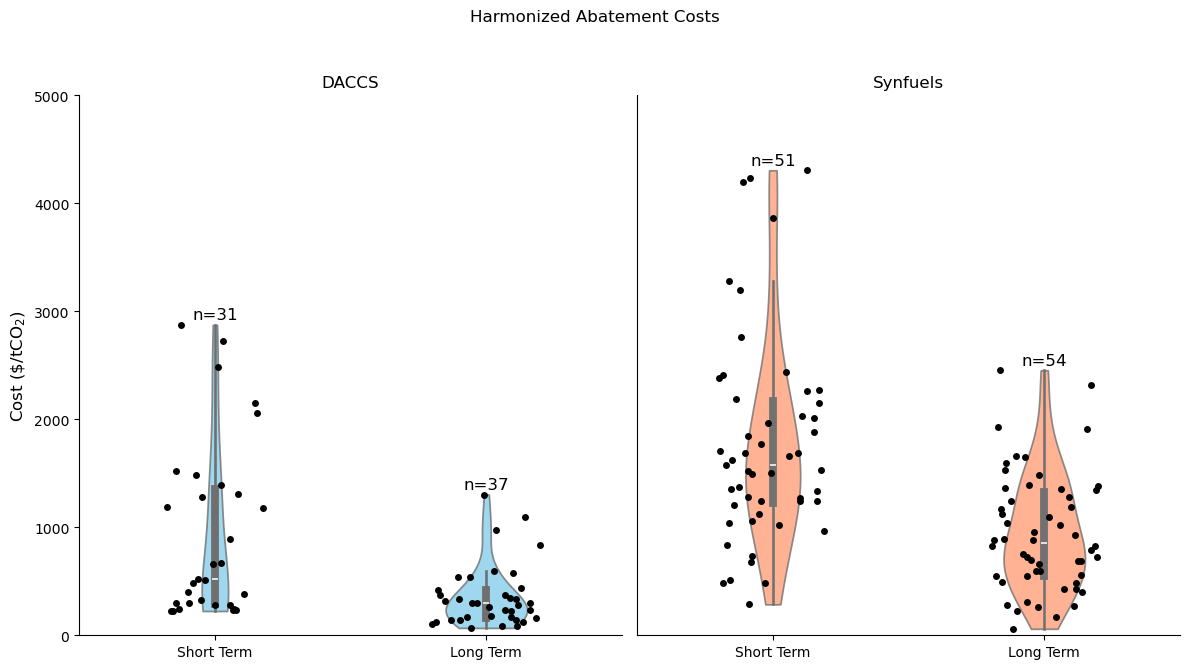

In [93]:
# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
fig.suptitle('Harmonized Abatement Costs')
plt.ylim(0, 5000)

# DACCS Studies violin plot with a single color
sns.violinplot(
    data=daccs_df, x="Term", y="Fully Harmonized NET REMOVED COST (incl T&S", 
    inner="box", color="skyblue", saturation=1, cut=0, width=0.3, orient='v', alpha=0.8, ax=axs[0]
)
# Add data points as a scatter plot with jitter
sns.stripplot(
    data=daccs_df, x="Term", y="Fully Harmonized NET REMOVED COST (incl T&S", 
    color="black", size=5, jitter=0.2, ax=axs[0]
)
# Annotate with the number of data points
for term, subset in daccs_df.groupby("Term"):
    count = len(subset)
    axs[0].text(term, subset["Fully Harmonized NET REMOVED COST (incl T&S"].max() + 50,  # Positioning just above the median
                f'n={count}', ha='center', color="black", fontsize=12)

axs[0].set_ylabel(r'Cost (\$/tCO$_2$)', fontsize=12)

# Synfuels Studies violin plot with a single color
sns.violinplot(
    data=synfuels_df, x="Term", y="Fully Harmonized", 
    inner="box", color="lightsalmon", saturation=1, cut=0, width=0.3, orient='v', alpha=0.8, ax=axs[1]
)
# Add data points as a scatter plot with jitter
sns.stripplot(
    data=synfuels_df, x="Term", y="Fully Harmonized", 
    color="black", size=5, jitter=0.2, ax=axs[1]
)
# Annotate with the number of data points
for term, subset in synfuels_df.groupby("Term"):
    count = len(subset)
    axs[1].text(term, subset["Fully Harmonized"].max() + 50,  # Positioning just above the median
                f'n={int(count)}', ha='center', color="black", fontsize=12)

# Set titles
axs[0].set_title('DACCS')
axs[1].set_title('Synfuels')

# Remove x-axis label on both panels
axs[0].set_xlabel("")
axs[1].set_xlabel("")

# Hide y-axis ticks on the second panel
axs[1].tick_params(left=False)

# Hide top and right spines for a cleaner look
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
plt.show()

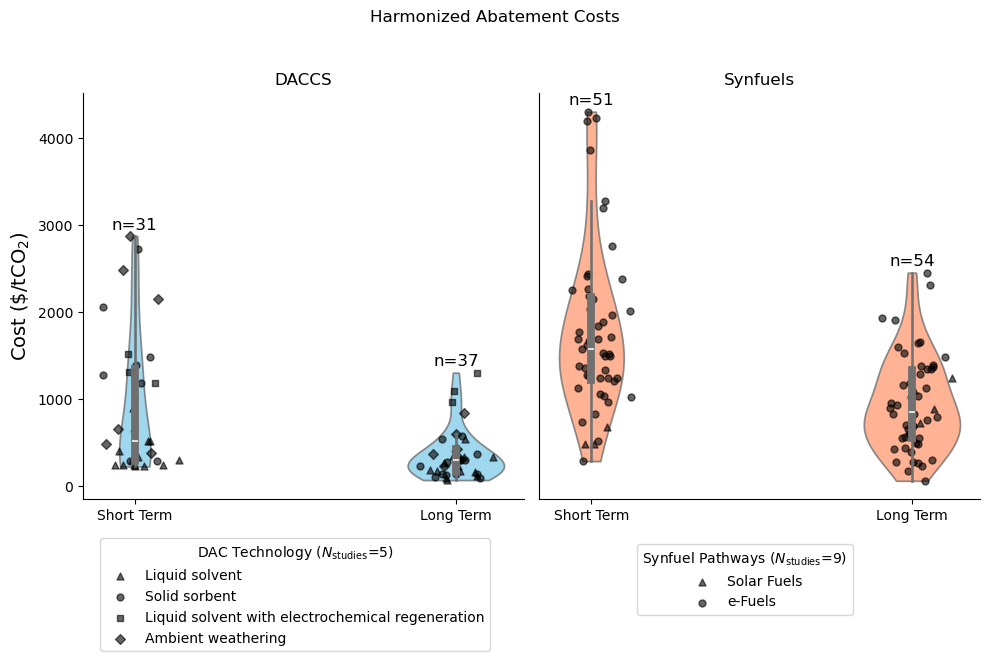

In [94]:
# Define symbol dictionaries
dac_symbols = {
    'Liquid solvent': "^",
    'Solid sorbent': "o",
    'Liquid solvent with electrochemical regeneration': "s",
    'Ambient weathering': "D"
}

synfuel_symbols = {
    'Solar Fuels': "^",
    'e-Fuels': "o"
}

# Count unique references for DACCS and Synfuels
num_dac_studies = daccs_df['Reference'].nunique()
num_synfuel_studies = synfuels_df['Reference'].nunique()

# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
fig.suptitle('Harmonized Abatement Costs')

# DACCS Studies violin plot with single color
sns.violinplot(
    data=daccs_df, x="Term", y="Fully Harmonized NET REMOVED COST (incl T&S", 
    inner="box", color="skyblue", saturation=1, cut=0, width=0.3, orient='v', alpha=0.8, ax=axs[0]
)

# Overlay symbols with jittered scatter points for DACCS studies
terms_dac = daccs_df['Term'].unique()
term_to_index_dac = {term: idx for idx, term in enumerate(terms_dac)}

for dac_type, marker in dac_symbols.items():
    subset = daccs_df[daccs_df['DAC Technology'] == dac_type]
    x_jittered = [term_to_index_dac[term] + np.random.normal(0, 0.05) for term in subset['Term']]
    axs[0].scatter(
        x=x_jittered,  # jittered x-position
        y=subset["Fully Harmonized NET REMOVED COST (incl T&S"], 
        color="black", s=25, alpha=0.6, marker=marker, label=dac_type
    )

# Annotate with number of data points
for term, subset in daccs_df.groupby("Term"):
    count = len(subset)
    axs[0].text(term_to_index_dac[term], subset["Fully Harmonized NET REMOVED COST (incl T&S"].max() + 75,
                f'n={count}', ha='center', color="black", fontsize=12)

axs[0].set_ylabel(r'Cost (\$/tCO$_2$)', fontsize=14)

# Synfuels Studies violin plot with single color
sns.violinplot(
    data=synfuels_df, x="Term", y="Fully Harmonized", 
    inner="box", color="lightsalmon", saturation=1, cut=0, width=0.3, orient='v', alpha=0.8, ax=axs[1]
)

# Overlay symbols with jittered scatter points for Synfuels
terms_synfuel = synfuels_df['Term'].unique()
term_to_index_synfuel = {term: idx for idx, term in enumerate(terms_synfuel)}

for synfuel_type, marker in synfuel_symbols.items():
    subset = synfuels_df[synfuels_df['Pathway'] == synfuel_type]
    x_jittered = [term_to_index_synfuel[term] + np.random.normal(0, 0.05) for term in subset['Term']]
    axs[1].scatter(
        x=x_jittered,  # jittered x-position
        y=subset["Fully Harmonized"], 
        color="black", s=25, alpha=0.6, marker=marker, label=synfuel_type
    )

# Annotate with number of data points
for term, subset in synfuels_df.groupby("Term"):
    count = len(subset)
    axs[1].text(term_to_index_synfuel[term], subset["Fully Harmonized"].max() + 75,
                f'n={int(count)}', ha='center', color="black", fontsize=12)

# Set titles
axs[0].set_title('DACCS')
axs[1].set_title('Synfuels')

# Remove x-axis label on both panels
axs[0].set_xlabel("")
axs[1].set_xlabel("")

# Hide y-axis ticks on the second panel
axs[1].tick_params(left=False)

# Hide top and right spines for a cleaner look
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set legends outside the subplots below the graph
fig.legend(handles=axs[0].get_legend_handles_labels()[0],
           labels=axs[0].get_legend_handles_labels()[1],
           loc='lower center', bbox_to_anchor=(0.3, -0.1), title=f"DAC Technology ($N_{{\\text{{studies}}}}$={num_dac_studies})")

fig.legend(handles=axs[1].get_legend_handles_labels()[0],
           labels=axs[1].get_legend_handles_labels()[1],
           loc='lower center', bbox_to_anchor=(0.75, -0.04), title=f"Synfuel Pathways ($N_{{\\text{{studies}}}}$={num_synfuel_studies})")

# Remove grids
axs[0].grid(False)
axs[1].grid(False)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Adjust layout to fit title and legends
plt.show()

In [95]:
daccs_cost_stats = daccs_df.groupby("Term")["Fully Harmonized NET REMOVED COST (incl T&S"].describe()
daccs_cost_stats.to_excel("../outputs/DACCS Cost Statistics.xlsx")

In [96]:
# Original percentiles from the table
short_term_25th = daccs_cost_stats['25%']['Short Term']
short_term_75th = daccs_cost_stats['75%']['Short Term']
long_term_25th = daccs_cost_stats['25%']['Long Term']
long_term_75th = daccs_cost_stats['75%']['Long Term']

# Define years and create an array to interpolate over
years = np.arange(2025, 2051, 5)

# Linear interpolation between 2025 (Short Term) and 2050 (Long Term)
percentile_25th_values_daccs = np.linspace(short_term_25th, long_term_25th, len(years))
percentile_75th_values_daccs = np.linspace(short_term_75th, long_term_75th, len(years))

# Create a DataFrame to store the interpolated values
interpolated_table = pd.DataFrame({
    'Year': years,
    '25th Percentile': percentile_25th_values_daccs,
    '75th Percentile': percentile_75th_values_daccs
})

# Set 'Year' as the index for a cleaner table display
interpolated_table.set_index('Year', inplace=True)

interpolated_table.to_excel("../outputs/Daccs_interpolated_table.xlsx")

In [97]:
# Same for synfuels
synfuels_cost_stats = synfuels_df.groupby("Term")["Fully Harmonized"].describe()
synfuels_cost_stats.to_excel("../outputs/Synfuels Cost Statistics.xlsx")

NameError: name 'percentile_25th_values_synfuels' is not defined

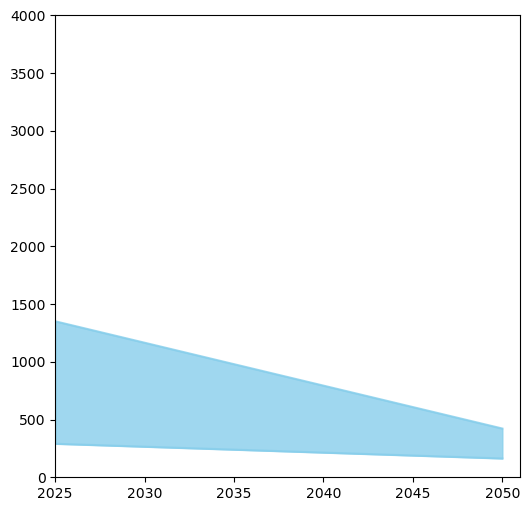

In [98]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.ylim(0, 4000)
plt.xlim(2025, 2051)

# Plot DACCS
ax.plot(years, percentile_25th_values_daccs, color='skyblue', alpha=0.8)
ax.plot(years, percentile_75th_values_daccs, color='skyblue', alpha=0.8)
ax.fill_between(years, percentile_25th_values_daccs, percentile_75th_values_daccs, color='skyblue', alpha=0.8)

# Plot Synfuels
ax.plot(years, percentile_25th_values_synfuels, color='lightsalmon', alpha=0.8)
ax.plot(years, percentile_75th_values_synfuels, color='lightsalmon', alpha=0.8)
ax.fill_between(years, percentile_25th_values_synfuels, percentile_75th_values_synfuels, color='lightsalmon', alpha=0.8)

# Custom legend patches
daccs_patch = mpatches.Patch(color='skyblue', label='DACCS')
synfuels_patch = mpatches.Patch(color='lightsalmon', label='Synfuels')

# Add custom legend
ax.legend(handles=[daccs_patch, synfuels_patch], loc='upper right')

# Hide top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the title and labels
ax.set_title('Harmonized Abatement Cost Trajectory')
ax.set_xlabel('Year')
ax.set_ylabel(r'Cost (\$/tCO$_2$)', fontsize=14)

# Remove grid
ax.grid(False)

# Add bracket markers and text at the end of each plot region
end_year = 2050
dac_25th = percentile_25th_values_daccs[-1]
dac_75th = percentile_75th_values_daccs[-1]
synfuel_25th = percentile_25th_values_synfuels[-1]
synfuel_75th = percentile_75th_values_synfuels[-1]

# Synfuels bracket and text
ax.vlines(end_year, synfuel_25th, synfuel_75th, color='black', linewidth=1.5)
ax.hlines([synfuel_25th, synfuel_75th], end_year - 0.2, end_year + 0.2, color='black', linewidth=1.5)
ax.text(end_year + 0.3, (synfuel_25th + synfuel_75th) / 2, 'Interquartile Range', color='black', va='center', fontsize=8)

plt.show()

In [71]:
interpolated_table.to_excel("cost_table_daccs.xlsx")

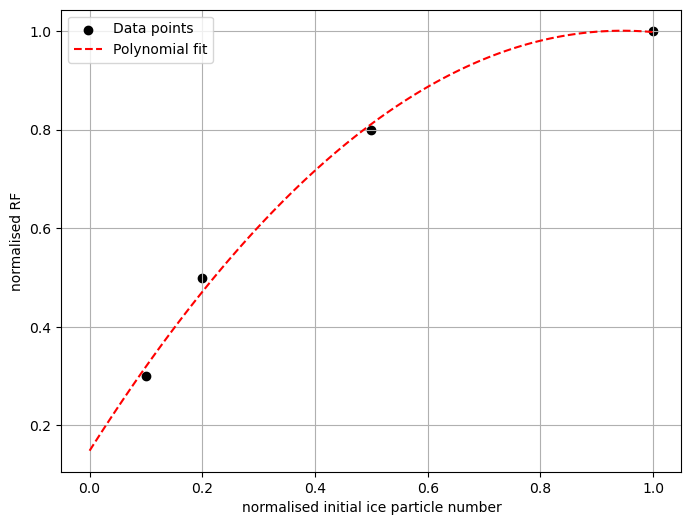

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data points
x = np.array([0.1, 0.2, 0.5, 1.0])
y = np.array([0.3, 0.5, 0.8, 1.0])

# Define polynomial function for fitting
def poly_func(x, a, b, c):
    return a*x**2 + b*x + c

# Fit curve
popt, _ = curve_fit(poly_func, x, y)

# Generate points for smooth curve
x_smooth = np.linspace(0, 1, 100)
y_smooth = poly_func(x_smooth, *popt)

# Create plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='black', label='Data points')
plt.plot(x_smooth, y_smooth, '--', color='red', label='Polynomial fit')
plt.xlabel('normalised initial ice particle number')
plt.ylabel('normalised RF')
plt.grid(True)
plt.legend()

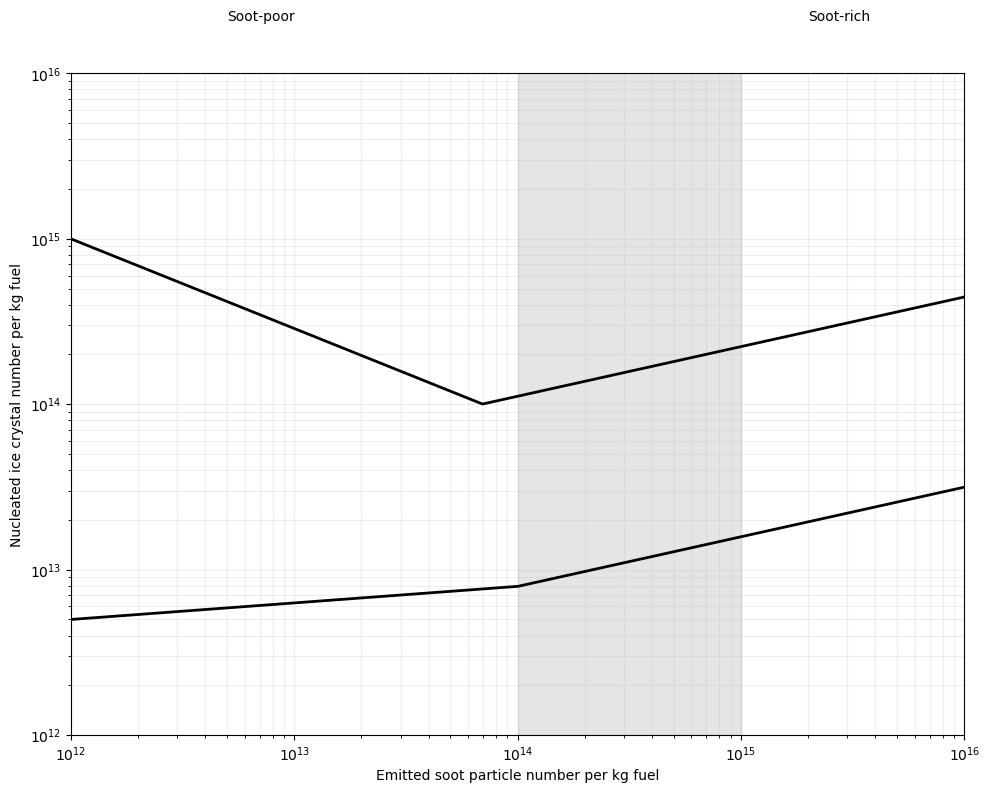

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create data points
x = np.logspace(12, 16, 1000)  # X-axis from 10^12 to 10^16
y1 = np.zeros_like(x)
y2 = np.zeros_like(x)

# Upper curve (first line)
mask1 = x < 7e13  # Three subticks before 10^14
mask2 = x >= 7e13

# Linear decline in log space
log_slope = (np.log10(1e14) - np.log10(1e15)) / (np.log10(7e13) - np.log10(1e12))
y1[mask1] = 10**(np.log10(1e15) + log_slope * (np.log10(x[mask1]) - np.log10(1e12)))

# Directly start linear upward trajectory from the end of decline
start_y = y1[mask1][-1]
y1[mask2] = start_y * (x[mask2]/7e13)**(0.3)

# Lower curve (second line)
mask_lower1 = x < 1e14
mask_lower2 = x >= 1e14

# Gentle curve until 10^14
y2[mask_lower1] = 5e12 * (x[mask_lower1]/1e12)**(0.1)

# Linear after 10^14 in log space
log_slope_lower = 0.3  # Controls the steepness of the linear part
y2[mask_lower2] = y2[mask_lower1][-1] * (x[mask_lower2]/1e14)**(log_slope_lower)

# Create the plot
plt.figure(figsize=(10, 8))
plt.loglog(x, y1, 'k-', linewidth=2)
plt.loglog(x, y2, 'k-', linewidth=2)

# Add gray shaded region
plt.axvspan(1e14, 1e15, color='gray', alpha=0.2)

# Set axis labels
plt.xlabel('Emitted soot particle number per kg fuel')
plt.ylabel('Nucleated ice crystal number per kg fuel')

# Set axis limits
plt.xlim(1e12, 1e16)
plt.ylim(1e12, 1e16)

# Set grid
plt.grid(True, which="both", ls="-", alpha=0.2)

# Add "Soot-poor" and "Soot-rich" text at the top
plt.annotate('Soot-poor', xy=(1e12, 1e16), xytext=(5e12, 2e16),
            xycoords='data', textcoords='data',
            ha='left', va='bottom')
plt.annotate('Soot-rich', xy=(1e15, 1e16), xytext=(2e15, 2e16),
            xycoords='data', textcoords='data',
            ha='left', va='bottom')

plt.tight_layout()
plt.show()

In [2]:
def get_nucleated_ice_crystals(emitted_soot_particles, curve='both'):
    """
    Calculate nucleated ice crystal number for a given emitted soot particle number.
    
    Parameters:
    emitted_soot_particles (float or array): Number of emitted soot particles per kg fuel
    curve (str): Which curve to calculate - 'upper', 'lower', or 'both' (default)
    
    Returns:
    float or tuple: Nucleated ice crystal number(s) per kg fuel
    """
    if isinstance(emitted_soot_particles, (list, np.ndarray)):
        x = np.array(emitted_soot_particles)
    else:
        x = np.array([emitted_soot_particles])
    
    # Initialize arrays
    y1 = np.zeros_like(x, dtype=float)
    y2 = np.zeros_like(x, dtype=float)
    
    # Upper curve calculations
    mask1 = x < 7e13
    mask2 = x >= 7e13
    
    # Linear decline in log space
    log_slope = (np.log10(1e14) - np.log10(1e15)) / (np.log10(7e13) - np.log10(1e12))
    y1[mask1] = 10**(np.log10(1e15) + log_slope * (np.log10(x[mask1]) - np.log10(1e12)))
    
    # Linear upward trajectory
    start_y = 10**(np.log10(1e15) + log_slope * (np.log10(7e13) - np.log10(1e12)))
    y1[mask2] = start_y * (x[mask2]/7e13)**(0.3)
    
    # Lower curve calculations
    mask_lower1 = x < 1e14
    mask_lower2 = x >= 1e14
    
    # Gentle curve until 10^14
    y2[mask_lower1] = 5e12 * (x[mask_lower1]/1e12)**(0.1)
    
    # Linear after 10^14
    log_slope_lower = 0.3
    y2[mask_lower2] = y2[mask_lower1][-1] * (x[mask_lower2]/1e14)**(log_slope_lower)
    
    # Return results based on requested curve
    if curve.lower() == 'upper':
        return y1[0] if len(x) == 1 else y1
    elif curve.lower() == 'lower':
        return y2[0] if len(x) == 1 else y2
    else:  # both
        return (y1[0], y2[0]) if len(x) == 1 else (y1, y2)